In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# Import data
macro_data = pd.read_csv('..\data\B_MacroConfidenceData.csv')
macro_data['date'] = pd.to_datetime(macro_data['date'])
macro_data.head()

<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\nhipk\AppData\Local\Temp\ipykernel_20288\94921104.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  macro_data = pd.read_csv('..\data\B_MacroConfidenceData.csv')


,date,ifo_business_climate,ifo_business_situation,ifo_business_expectations,de_economic_sentiment_index,de_employment_expectations_index,de_industry_confidence,de_services_confidence,de_consumer_confidence,de_retail_confidence,de_construction_confidence
0,2009-01-01,81.7,82.1,81.3,75.1,80.3,-37.5,-11.2,-19.6,-29.8,-29.7
1,2009-02-01,81.3,80.0,82.7,73.5,79.0,-41.3,-11.9,-19.9,-25.9,-29.8
2,2009-03-01,79.7,77.5,82.0,72.8,78.1,-42.0,-13.9,-20.6,-26.9,-28.7
3,2009-04-01,81.5,78.3,84.8,75.1,78.5,-39.7,-10.8,-19.3,-22.3,-29.5
4,2009-05-01,82.0,77.7,86.6,77.3,80.8,-37.9,-7.4,-18.7,-21.4,-30.5


### 1. Check data strcture

In [11]:
# Does the data contain any missing values?
macro_data.isnull().sum()

date                                0
ifo_business_climate                0
ifo_business_situation              0
ifo_business_expectations           0
de_economic_sentiment_index         0
de_employment_expectations_index    0
de_industry_confidence              0
de_services_confidence              0
de_consumer_confidence              0
de_retail_confidence                0
de_construction_confidence          0
dtype: int64

In [12]:
# Check if there are any dates that are omitted in the period of time that we are looking at
max_date = macro_data['date'].max()
min_date = macro_data['date'].min()
selected_dates = pd.date_range(start=min_date, end=max_date, freq='ME')
missing_dates = selected_dates.to_period('ME').difference(
    pd.to_datetime(macro_data['date']).dt.to_period('ME')
)
number_of_missing_dates = len(missing_dates)

print(f'The number of missing dates in the data is: {number_of_missing_dates}')
print(f'The missing dates are: {missing_dates}')

ValueError: Invalid frequency: ME. Failed to parse with error message: ValueError("for Period, please use 'M' instead of 'ME'")

The data is comprehensive. There is no missing date in the data

### 2. Univariate analysis

In [14]:
# Descriptive Statistics
macro_data.describe()

,date,ifo_business_climate,ifo_business_situation,ifo_business_expectations,de_economic_sentiment_index,de_employment_expectations_index,de_industry_confidence,de_services_confidence,de_consumer_confidence,de_retail_confidence,de_construction_confidence
count,192,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,2016-12-15 17:00:00,95.841146,96.445833,95.345833,102.373958,104.155729,-2.693229,11.867188,-6.009375,-9.516667,-3.961458
min,2009-01-01 00:00:00,75.000000,77.500000,71.000000,67.000000,73.600000,-42.000000,-39.800000,-28.000000,-46.100000,-30.500000
25%,2012-12-24 06:00:00,91.075000,93.175000,91.950000,97.875000,100.175000,-10.375000,7.550000,-10.050000,-15.900000,-11.700000
50%,2016-12-16 12:00:00,98.000000,98.600000,97.750000,104.600000,105.600000,-1.450000,13.800000,-3.850000,-7.550000,-5.350000
75%,2020-12-08 18:00:00,100.600000,100.900000,100.400000,108.625000,110.275000,6.700000,18.925000,-0.600000,-3.300000,5.425000
max,2024-12-01 00:00:00,105.000000,108.400000,106.100000,118.900000,118.800000,24.200000,24.300000,2.300000,10.400000,20.900000
std,NaN,6.296556,7.317059,6.782460,9.616339,8.793439,13.328468,9.959053,6.828414,9.012675,13.062575


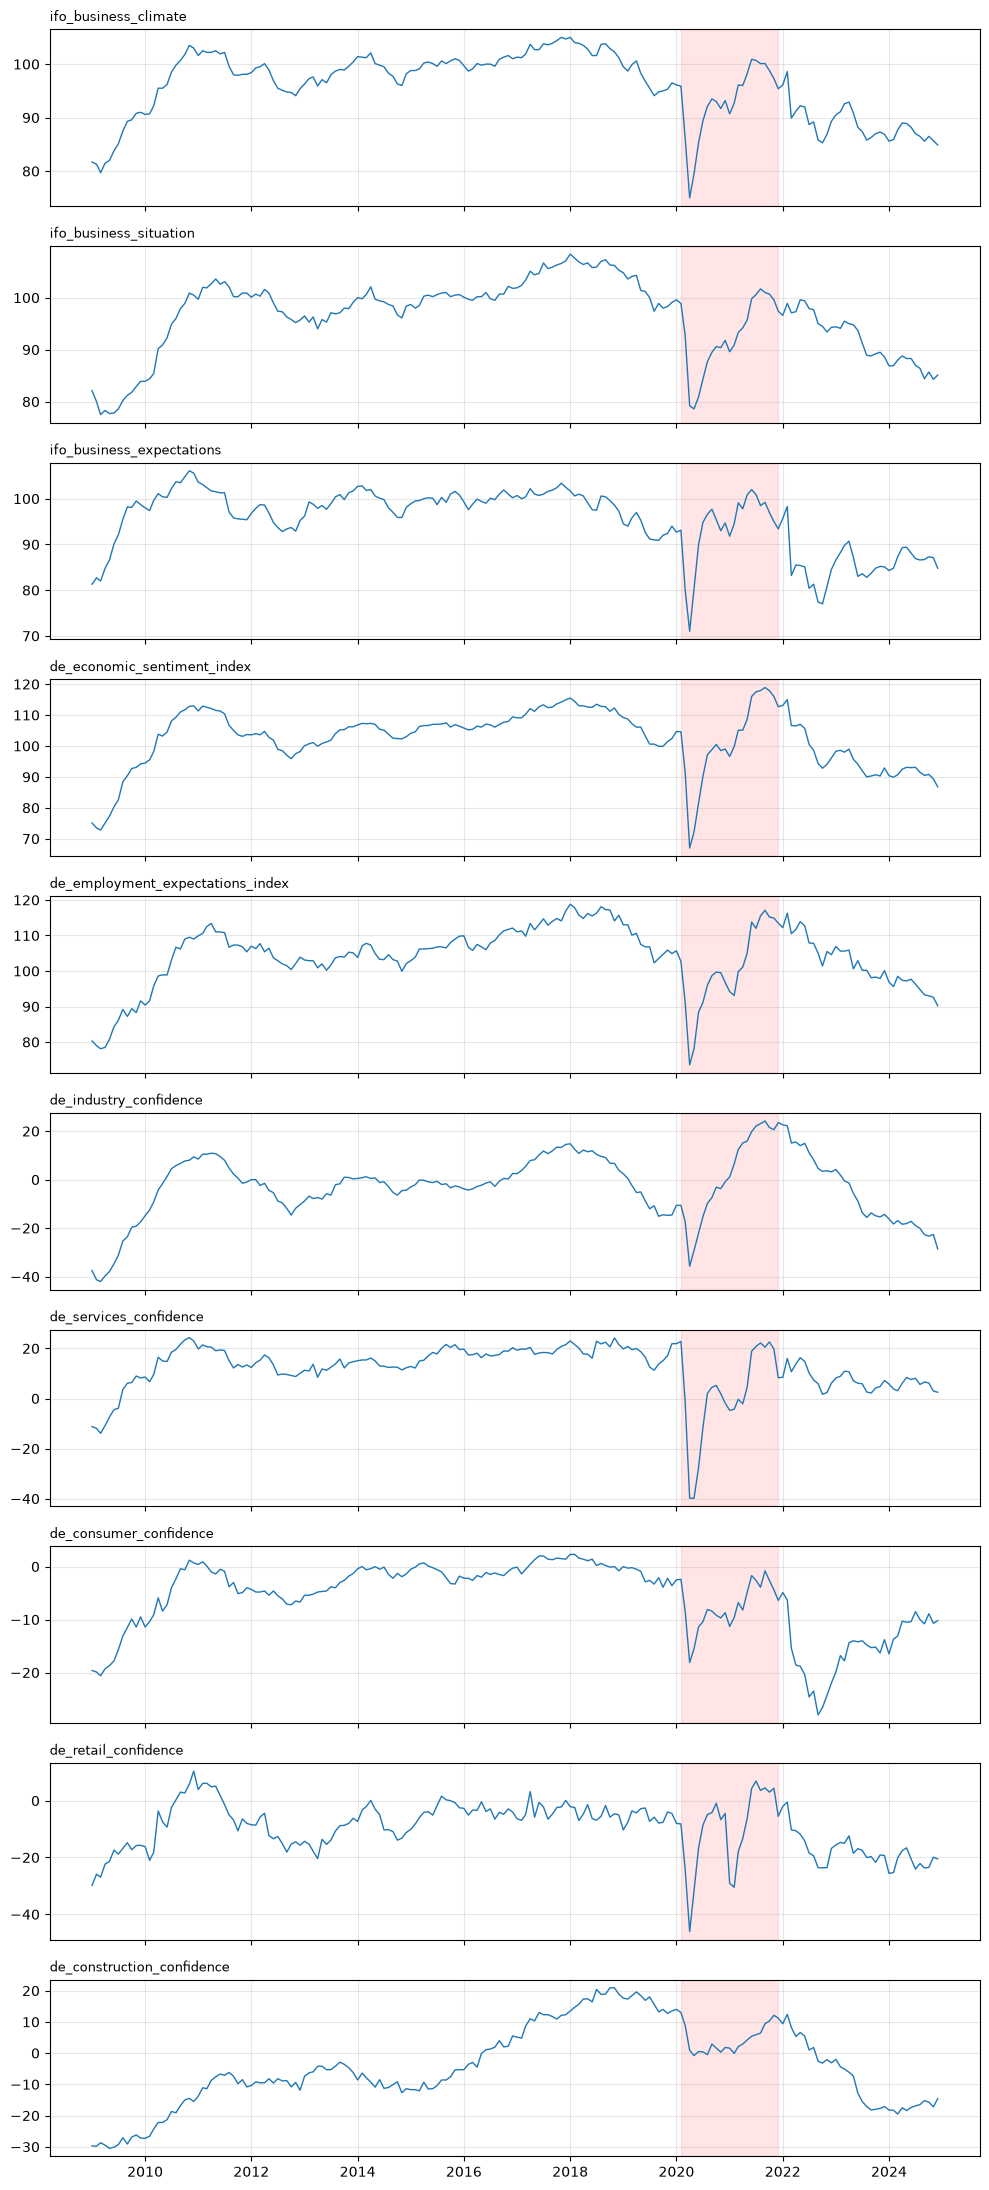

In [15]:
series = [c for c in macro_data.columns if c != 'date']
fig, axes = plt.subplots(len(series), 1, figsize=(10, 2.2 * len(series)), sharex=True)

for ax, col in zip(axes, series):
    ax.plot(macro_data['date'], macro_data[col], linewidth=1)
    ax.set_title(col, loc='left', fontsize=9)
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2021-12-01'), color='red', alpha=0.1) # COVID-19 pandemic period
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


These macro confidence factors have the almost same trend. In addition, there are fluctuations in COVID-19 pandemic.
In addition, these time series seem stationary, which can avoid the issue of non-stationary serios: significant coefficients reflect the same trend of dependent and independent variable rather than causal relationship.

### 3. Multivariate Time Series Analysis

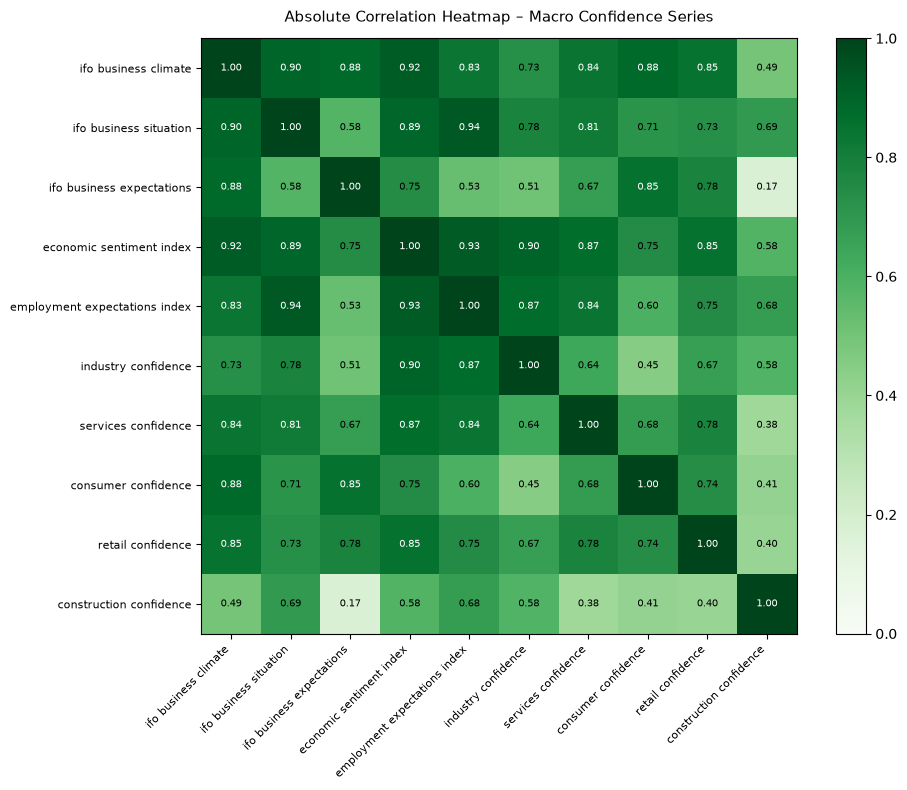

In [16]:
corr = macro_data[series].corr().abs() 

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='Greens', vmin=0, vmax=1) 
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(series)))
ax.set_yticks(range(len(series)))
short = [c.replace('de_', '').replace('ifo_', 'ifo ').replace('_', ' ') for c in series]
ax.set_xticklabels(short, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short, fontsize=8)

for i in range(len(series)):
    for j in range(len(series)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='black' if corr.iloc[i, j] < 0.8 else 'white')

ax.set_title('Absolute Correlation Heatmap – Macro Confidence Series', fontsize=11, pad=12)
plt.tight_layout()

### 4. Feature engineering

In [17]:
# Annualized the indicators by calculating year mean
macro_data['year'] = macro_data['date'].dt.year
annualized_data_average = macro_data.groupby('year')[series].mean()
annualized_data_average

# Annualized the indicators by getting value of December of each year
annualized_data_december = macro_data[macro_data['date'].dt.month == 12]
annualized_data_december

# Create growth rates for each indicator
growth_rates = macro_data.copy().sort_values('date')
for col in series:
    growth_rates[col + '_growth'] = growth_rates[col].pct_change() * 100
growth_rates

,date,ifo_business_climate,ifo_business_situation,ifo_business_expectations,de_economic_sentiment_index,de_employment_expectations_index,de_industry_confidence,de_services_confidence,de_consumer_confidence,de_retail_confidence,...,ifo_business_climate_growth,ifo_business_situation_growth,ifo_business_expectations_growth,de_economic_sentiment_index_growth,de_employment_expectations_index_growth,de_industry_confidence_growth,de_services_confidence_growth,de_consumer_confidence_growth,de_retail_confidence_growth,de_construction_confidence_growth
0,2009-01-01,81.7,82.1,81.3,75.1,80.3,-37.5,-11.2,-19.6,-29.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-02-01,81.3,80.0,82.7,73.5,79.0,-41.3,-11.9,-19.9,-25.9,...,-0.489596,-2.557856,1.722017,-2.130493,-1.618929,10.133333,6.250000,1.530612,-13.087248,0.336700
2,2009-03-01,79.7,77.5,82.0,72.8,78.1,-42.0,-13.9,-20.6,-26.9,...,-1.968020,-3.125000,-0.846433,-0.952381,-1.139241,1.694915,16.806723,3.517588,3.861004,-3.691275
3,2009-04-01,81.5,78.3,84.8,75.1,78.5,-39.7,-10.8,-19.3,-22.3,...,2.258469,1.032258,3.414634,3.159341,0.512164,-5.476190,-22.302158,-6.310680,-17.100372,2.787456
4,2009-05-01,82.0,77.7,86.6,77.3,80.8,-37.9,-7.4,-18.7,-21.4,...,0.613497,-0.766284,2.122642,2.929427,2.929936,-4.534005,-31.481481,-3.108808,-4.035874,3.389831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,2024-08-01,86.5,86.4,86.6,91.5,94.8,-20.1,5.6,-10.0,-22.1,...,-0.574713,-0.689655,-0.345224,-1.718582,-1.557632,6.349206,-30.864198,17.647059,-8.298755,-2.366864
188,2024-09-01,85.6,84.4,86.7,90.5,93.3,-22.7,6.6,-10.8,-23.7,...,-1.040462,-2.314815,0.115473,-1.092896,-1.582278,12.935323,17.857143,8.000000,7.239819,-7.878788
189,2024-10-01,86.5,85.7,87.3,90.8,93.0,-23.3,6.2,-8.9,-23.5,...,1.051402,1.540284,0.692042,0.331492,-0.321543,2.643172,-6.060606,-17.592593,-0.843882,3.289474
190,2024-11-01,85.7,84.3,87.1,89.4,92.6,-22.6,3.0,-10.7,-19.9,...,-0.924855,-1.633606,-0.229095,-1.541850,-0.430108,-3.004292,-51.612903,20.224719,-15.319149,9.554140


In [19]:
# Rename 'old_name' to 'new_name'
growth_rates = growth_rates.rename(columns={"date": "report_date"})
# Save output for further analysis
growth_rates.to_csv(r'..\data\model_input\df_processed_macro.csv', index = False)